# Testing the PILCO framework

In [1]:
# %load ~/dev/marthaler/header.py
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

%load_ext autoreload
%autoreload 2

In [2]:
# Enable Float64 for more stable matrix inversions.
from jax import Array, config
import jax.numpy as jnp
import jax.random as jr
from jaxtyping import ArrayLike, install_import_hook
import matplotlib as mpl
import matplotlib.pyplot as plt

config.update("jax_enable_x64", True)
import gpjax as gpx


key = jr.key(123)

cols = mpl.rcParams["axes.prop_cycle"].by_key()["color"]

/Users/daniel.marthaler/.pyenv/versions/3.11.1/envs/pilco/lib/python3.11/site-packages/cola/backends/backends.py:75: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(cls, tree_flatten, tree_unflatten)


In [6]:
from typing import Generator

In [4]:
import gymnasium as gym
env = gym.make("InvertedPendulum-v5")

In [5]:
type(env)

gymnasium.wrappers.common.TimeLimit

In [ ]:
def policy(env: gym.wrappers.common.TimeLimit, pilco, x: Array, random: bool)-> Generator[float, None, None]:
    if random:
        return env.action_space.sample()
    else:
        return pilco.compute_action(x[None, :])[0, :]

In [ ]:
def rollout(
    env: gym.wrappers.common.TimeLimit,
    pilco,
    timesteps: int,
    verbose: bool=True,
    random: bool=False,
    SUBS: int=1,
    render: bool=False
):
    X = []
    Y = []
    x = env.reset()
    ep_return_full = 0
    ep_return_sampled = 0
    for timestep in range(timesteps):
        if render:
            env.render()
        u = policy(env, pilco, x, random)
        for i in range(SUBS):
            x_new, r, done, _ = env.step(np.array(u))
            ep_return_full += r
            if done:
                break
            if render:
                env.render()
        if verbose:
            print("Action: ", u)
            print("State : ", x_new)
            print("Return so far: ", ep_return_full)
        X.append(jnp.hstack((x, u)))
        Y.append(x_new - x)
        ep_return_sampled += r
        x = x_new
        if done:
            break
    return jnp.stack(X), jnp.stack(Y), ep_return_sampled, ep_return_full

In [101]:
n = 100
noise = 0.3

key, subkey = jr.split(key)
x = jr.uniform(key=key, minval=-3.0, maxval=3.0, shape=(n,)).reshape(-1, 1)
f = lambda x: jnp.sin(4 * x) + jnp.cos(2 * x)
signal = f(x)
y = signal + jr.normal(subkey, shape=signal.shape) * noise

D = gpx.Dataset(X=x, y=y)

In [102]:
from mgpr import DynamicalModel

In [103]:
model = DynamicalModel(data=D,targets=True)

/var/folders/rk/49593z6j4xx_hxmgmkhxh50w0000gq/T/ipykernel_88205/3660018539.py:1: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  model = DynamicalModel(data=D,targets=True)


In [104]:
model.optimize()

  0%|          | 0/1000 [00:00<?, ?it/s]

In [105]:
xtest = jnp.linspace(-3.5, 3.5, 500).reshape(-1, 1)
ytest = f(xtest)

In [10]:
predictive_moments = model.predict_all_outputs(xtest)

/Users/daniel.marthaler/.pyenv/versions/3.11.1/envs/pilco/lib/python3.11/site-packages/cola/backends/backends.py:75: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(cls, tree_flatten, tree_unflatten)


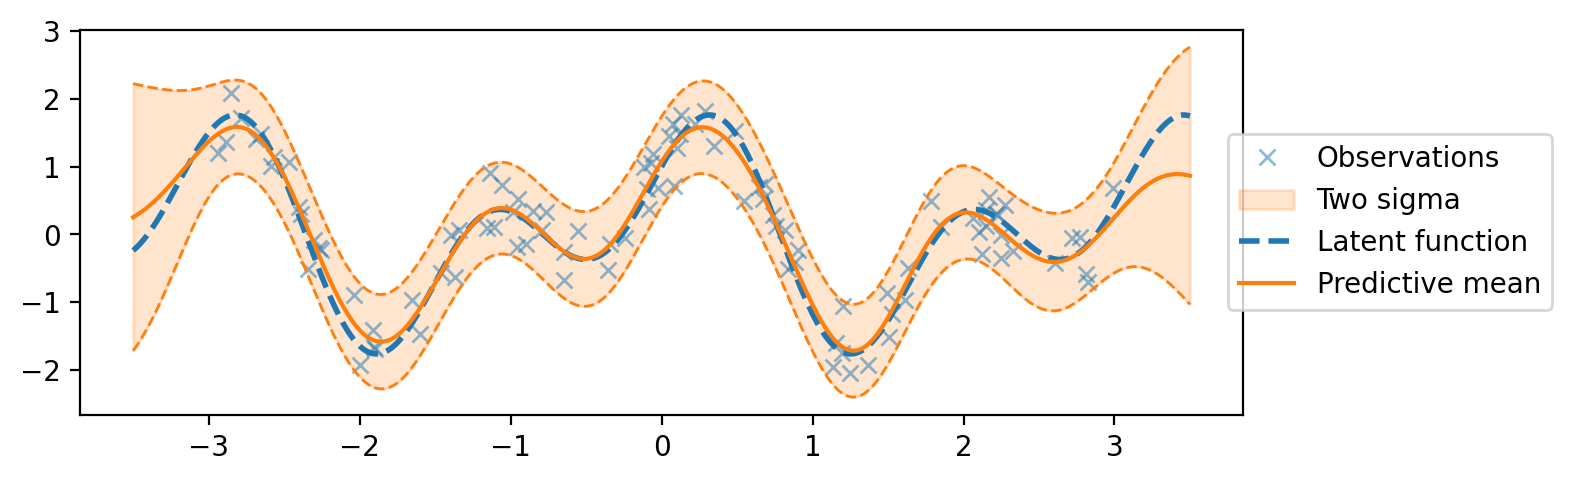

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 2.5))
ax.plot(x, y, "x", label="Observations", color=cols[0], alpha=0.5)
ax.fill_between(
    xtest.squeeze(),
    predictive_moments[0][0] - 2 * predictive_moments[0][1],
    predictive_moments[0][0] + 2 * predictive_moments[0][1],
    alpha=0.2,
    label="Two sigma",
    color=cols[1],
)
ax.plot(
    xtest,
    predictive_moments[0][0] - 2 * predictive_moments[0][1],
    linestyle="--",
    linewidth=1,
    color=cols[1],
)
ax.plot(
    xtest,
    predictive_moments[0][0] + 2 * predictive_moments[0][1],
    linestyle="--",
    linewidth=1,
    color=cols[1],
)
ax.plot(
    xtest, ytest, label="Latent function", color=cols[0], linestyle="--", linewidth=2
)
ax.plot(xtest, predictive_moments[0][0], label="Predictive mean", color=cols[1])
ax.legend(loc="center left", bbox_to_anchor=(0.975, 0.5))
plt.show()

# Now have two D inputs

In [21]:
n = 100
noise = 0.3

key, subkey = jr.split(key)
x = jr.uniform(key=key, minval=-3.0, maxval=3.0, shape=(n,2))
f = lambda x: jnp.sin(4 * x[:,0]) + jnp.cos(2 * x[:,1])
signal = f(x).reshape(-1,1)
y = signal + jr.normal(subkey, shape=signal.shape) * noise

D = gpx.Dataset(X=x, y=y)

In [22]:
model = DynamicalModel(data=D,targets=True)

/var/folders/rk/49593z6j4xx_hxmgmkhxh50w0000gq/T/ipykernel_88205/3660018539.py:1: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  model = DynamicalModel(data=D,targets=True)


In [23]:
model.optimize()

  0%|          | 0/1000 [00:00<?, ?it/s]

In [24]:
xtest = jnp.linspace(-3.5, 3.5, 1000).reshape(500, 2)
ytest = f(xtest).reshape(-1,1)

In [22]:
latent_dist = model.models[0].predict(xtest, train_data=D)
predictive_dist = model.models[0].likelihood(latent_dist)

predictive_mean = predictive_dist.mean()
predictive_std = predictive_dist.stddev()

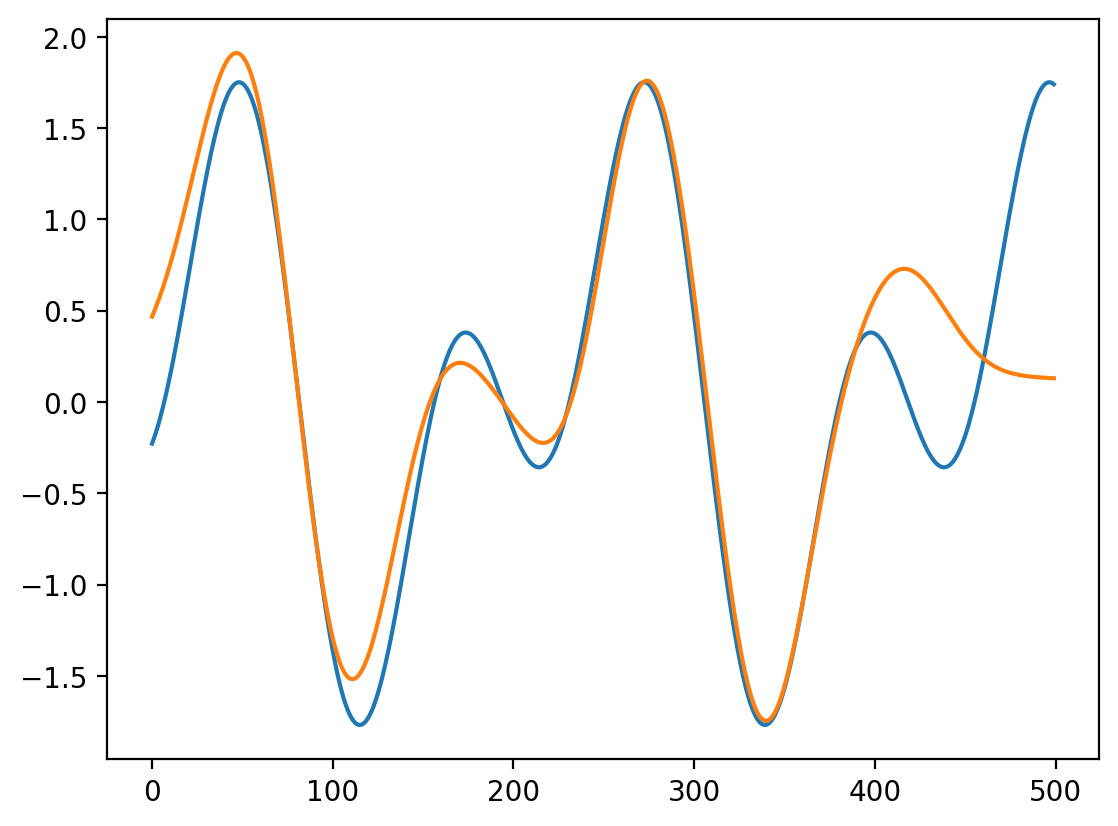

In [23]:
plt.plot(ytest)
plt.plot(predictive_mean)

Should use a different kernel! (and how should we plot this?)

# Try multiple outputs?

In [80]:
n = 100
noise = 0.3

key, subkey = jr.split(key)
# x = jr.uniform(key=key, minval=-3.0, maxval=3.0, shape=(n,2))
# f = lambda x: jnp.vstack((jnp.sin(4 * x[:,0]),jnp.cos(2 * x[:,1]))).T
x = jr.uniform(key=key, minval=-3.0, maxval=3.0, shape=(n,1))
f = lambda x: jnp.vstack((jnp.sin(4 * x[:,0]),jnp.cos(2 * x[:,0]))).T
signal = f(x)
y = signal + jr.normal(subkey, shape=signal.shape) * noise

D = gpx.Dataset(X=x, y=y)

In [81]:
model = DynamicalModel(data=D,targets=True)

/var/folders/rk/49593z6j4xx_hxmgmkhxh50w0000gq/T/ipykernel_88205/3660018539.py:1: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  model = DynamicalModel(data=D,targets=True)


In [82]:
model.optimize()

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

In [84]:
#xtest = jnp.linspace(-3.5, 3.5, 500).reshape(-1, 2)
xtest = jnp.linspace(-3.5, 3.5, 500).reshape(-1, 1)
ytest = f(xtest)

In [85]:
predictive_moments = model.predict_all_outputs(xtest)

In [86]:
predictive_mean = []
predictive_std = []
for i in range(len(model.models)):
    latent_dist = model.models[i].predict(xtest, train_data=gpx.Dataset(X=D.X, y=D.y[:,i].reshape(-1,1)))
    predictive_dist = model.models[0].likelihood(latent_dist)

    predictive_mean.append(predictive_dist.mean())
    predictive_std.append(predictive_dist.stddev())

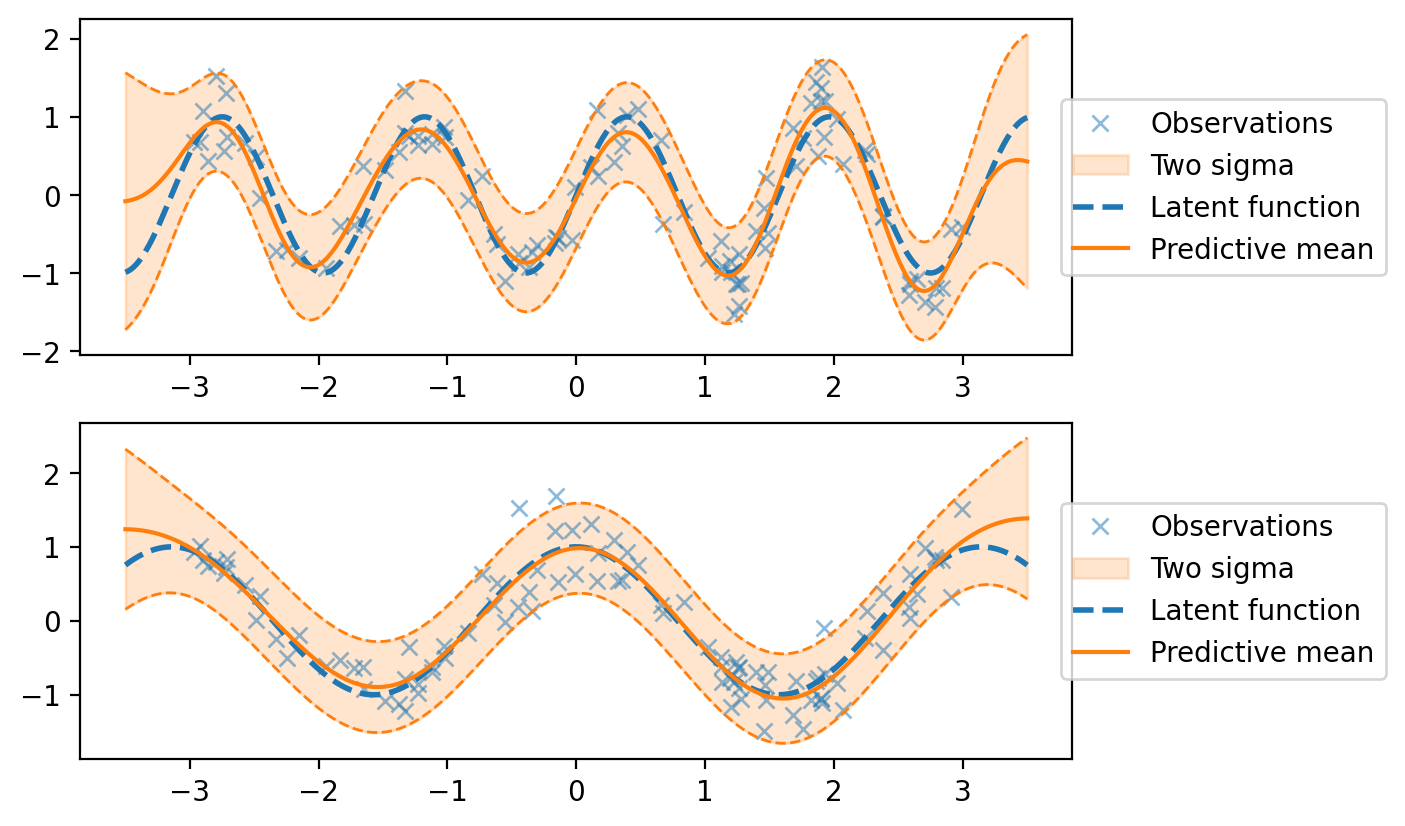

In [87]:
fig, ax = plt.subplots(2,1)
for i in range(2):
    ax[i].plot(x, y[:,i], "x", label="Observations", color=cols[0], alpha=0.5)
    ax[i].fill_between(
        xtest.squeeze(),
        predictive_mean[i] - 2 * predictive_std[i],
        predictive_mean[i] + 2 * predictive_std[i],
        alpha=0.2,
        label="Two sigma",
        color=cols[1],
    )
    ax[i].plot(
        xtest,
        predictive_mean[i] - 2 * predictive_std[i],
        linestyle="--",
        linewidth=1,
        color=cols[1],
    )
    ax[i].plot(
        xtest,
        predictive_mean[i] + 2 * predictive_std[i],
        linestyle="--",
        linewidth=1,
        color=cols[1],
    )
    ax[i].plot(
        xtest, ytest[:,i], label="Latent function", color=cols[0], linestyle="--", linewidth=2
    )
    ax[i].plot(xtest, predictive_mean[i], label="Predictive mean", color=cols[1])
    ax[i].legend(loc="center left", bbox_to_anchor=(0.975, 0.5))
plt.show()

In [88]:
predictive_moments.shape

(500, 2, 2)

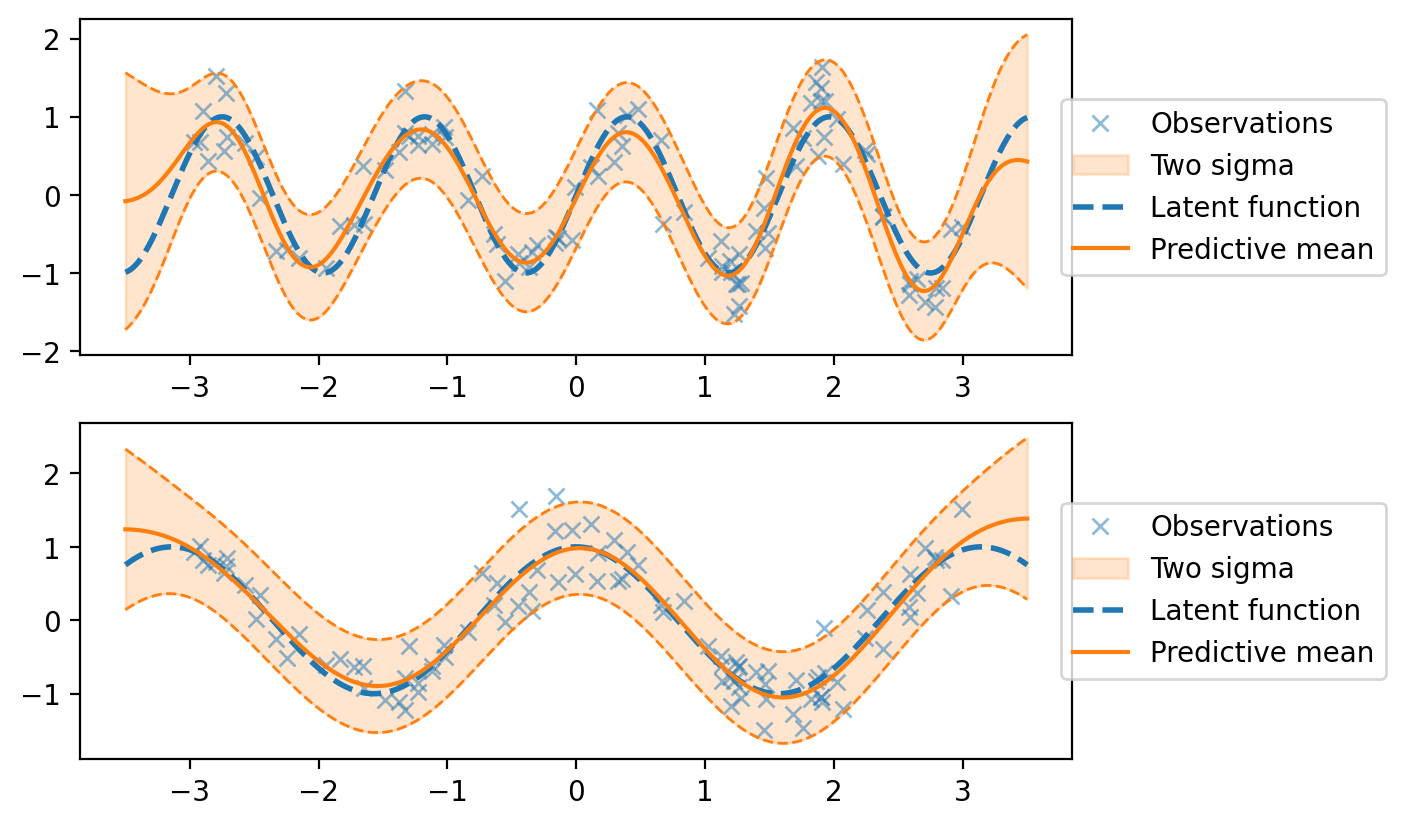

In [89]:
fig, ax = plt.subplots(2,1)
for i in range(2):
    ax[i].plot(x, y[:,i], "x", label="Observations", color=cols[0], alpha=0.5)
    ax[i].fill_between(
        xtest.squeeze(),
        predictive_moments[:,i,0] - 2 * predictive_moments[:,i,1],
        predictive_moments[:,i,0] + 2 * predictive_moments[:,i,1],
        alpha=0.2,
        label="Two sigma",
        color=cols[1],
    )
    ax[i].plot(
        xtest,
        predictive_moments[:,i,0] - 2 * predictive_moments[:,i,1],
        linestyle="--",
        linewidth=1,
        color=cols[1],
    )
    ax[i].plot(
        xtest,
        predictive_moments[:,i,0] + 2 * predictive_moments[:,i,1],
        linestyle="--",
        linewidth=1,
        color=cols[1],
    )
    ax[i].plot(
        xtest, ytest[:,i], label="Latent function", color=cols[0], linestyle="--", linewidth=2
    )
    ax[i].plot(xtest, predictive_moments[:,i,0], label="Predictive mean", color=cols[1])
    ax[i].legend(loc="center left", bbox_to_anchor=(0.975, 0.5))
plt.show()

## Sample from MVN

In [143]:
n = 100
noise = 0.3
input_dimension = 3

key, subkey = jr.split(key)
x = jr.uniform(key=key, minval=-3.0, maxval=3.0, shape=(n,input_dimension))
f = lambda x: jnp.vstack(
    (
        -1.1*jnp.sin(4 * x[:,0]) + x[:,4],
        2.0*jnp.cos(2 * x[:,1]),
        2.0*jnp.cos(2 * x[:,2]) + 3.5*jnp.sin(0.5 * x[:,3])
    )
).T
signal = f(x)
key, subkey = jr.split(key)
y = signal + jr.normal(subkey, shape=signal.shape) * noise

D = gpx.Dataset(X=x, y=y)

In [144]:
model = DynamicalModel(data=D,targets=True)
model.optimize()

/var/folders/rk/49593z6j4xx_hxmgmkhxh50w0000gq/T/ipykernel_88205/2758726911.py:1: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  model = DynamicalModel(data=D,targets=True)


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

In [146]:
xtest = jnp.linspace(-3.5, 3.5, 600).reshape(-1, input_dimension)
ytest = f(xtest)

In [147]:
predictive_moments = model.predict_all_outputs(xtest)

In [148]:
predictive_moments.shape

(200, 3, 2)

In [149]:
# Function to sample from a single mean and covariance
def sample_mvnormal(key, mean, cov, num_samples):
    return random.multivariate_normal(key, mean, cov, (num_samples,))

# Vectorize the sampling function
vectorized_sample = jax.vmap(sample_mvnormal, in_axes=(None, 0, 0, None))


In [152]:
# Generate samples
key, subkey = jr.split(key)
samples = jnp.squeeze(vectorized_sample(key, predictive_moments[:,:,0], jax.vmap(jnp.diag)(predictive_moments[:,:,1]), 1))

In [153]:
samples.shape, D.y.shape, xtest.shape

((200, 3), (100, 3), (200, 3))

In [138]:
S[0,:,:], predictive_moments[0,:,1]

(Array([[0.99657279, 0.        , 0.        ],
        [0.        , 0.68232068, 0.        ],
        [0.        , 0.        , 1.87863357]], dtype=float64),
 Array([0.99657279, 0.68232068, 1.87863357], dtype=float64))

In [123]:
import jax
## testing
key = jax.random.PRNGKey(0)
num_batches = 3
batch_size = 1#5
mean = jnp.array([[0.0, 0.0], [1.0, 1.0], [2.0, 2.0]])
cov = jnp.array([[[1.0, 0.0], [0.0, 1.0]],
                 [[0.5, 0.2], [0.2, 0.5]],
                 [[1.5, -0.3], [-0.3, 1.5]]])

In [133]:
# # vmap over the first axis of mean and cov
# batched_mvn = jax.vmap(jax.random.multivariate_normal, in_axes=(None, 0, 0, None))
# samples = batched_mvn(key, mean, cov, shape=(batch_size,))

# print(samples.shape) # Output: (3, 5, 2)

In [130]:
import jax
import jax.numpy as jnp
from jax import random

# Define the random key
key = random.PRNGKey(0)

# Define the means and covariance matrices
means = jnp.array([[0, 0], [1, 1], [2, 2]])
covs = jnp.array([[[1, 0.5], [0.5, 1]], [[1, 0.2], [0.2, 1]], [[1, 0.1], [0.1, 1]]])

# Number of samples to draw for each distribution
num_samples = 5

# Function to sample from a single mean and covariance
def sample_mvnormal(key, mean, cov, num_samples):
    return random.multivariate_normal(key, mean, cov, (num_samples,))

# Vectorize the sampling function
vectorized_sample = jax.vmap(sample_mvnormal, in_axes=(None, 0, 0, None))

# Generate samples
samples = vectorized_sample(key, means, covs, num_samples)

print(samples)


[[[ 1.05451609 -0.31217067]
  [-0.59460177 -0.32491479]
  [ 2.41093278 -0.42131778]
  [-0.78476944 -0.66406407]
  [ 0.33370904  1.69773081]]

 [[ 2.05451609  0.26119804]
  [ 0.40539823  0.84983808]
  [ 3.41093278 -0.35830963]
  [ 0.21523056  0.53567602]
  [ 1.33370904  2.79873062]]

 [[ 3.05451609  1.14102144]
  [ 1.40539823  1.90881386]
  [ 4.41093278  0.37206056]
  [ 1.21523056  1.60938725]
  [ 2.33370904  3.79221385]]]


In [131]:
means.shape, covs.shape

((3, 2), (3, 2, 2))

## Compare against matlab?

In [31]:
d = 3  # Input dimension
k = 2  # Number of outputs
b = 100  # Number of basis functions

key, subkey = jr.split(key)
x0 = jr.uniform(key=subkey, shape=(b,d))
key, subkey = jr.split(key)
A = jr.uniform(key=subkey, shape=(d,k))

key, subkey = jr.split(key)
y0 = jnp.sin(x0).dot(A) + 1e-3 *(jr.uniform(key=subkey, shape=(b, k)) - 0.5)

In [32]:
D = gpx.Dataset(X=x0,y=y0)

In [123]:
model = DynamicalModel(data=D,targets=True)

In [108]:
model.optimize()

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

In [72]:
# Generate input
key, subkey = jr.split(key)
input_mean = jr.uniform(key=subkey,shape=(1, d))  # But MATLAB defines it as m'
key, subkey = jr.split(key)
s = jr.uniform(key=subkey,shape=(d, d))
input_covariance = s.dot(s.T)  # Make s positive semidefinite

In [124]:
iK, beta = model.calculate_factorizations()

In [125]:
a,b,c = model.predict_given_factorizations(input_mean,input_covariance,iK,beta)

TypeError: dot_general requires contracting dimensions to have the same shape, got (3,) and (2,).

In [71]:
M, S, V = model.predict_on_noisy_inputs(m, s)

/Users/daniel.marthaler/.pyenv/versions/3.11.1/envs/pilco/lib/python3.11/site-packages/cola/backends/backends.py:75: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(cls, tree_flatten, tree_unflatten)


ValueError: dimension mismatch (2, 100, 100) vs (100, 100)

In [68]:
model.noise

Array([1.00161423e-06, 1.00162926e-06], dtype=float64)